# **Step 1-Import Libraries**

In [5]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import random
from collections import Counter

# **Step 2-Load Dataset**

In [9]:
DATASET_PATH = "../Dataset"


train_images = os.path.join(DATASET_PATH, "train", "images")
train_labels = os.path.join(DATASET_PATH, "train", "labels")

val_images = os.path.join(DATASET_PATH, "val", "images")
val_labels = os.path.join(DATASET_PATH, "val", "labels")

test_images = os.path.join(DATASET_PATH, "test", "images")
test_labels = os.path.join(DATASET_PATH, "test", "labels")

# **Step 3-Check Dataset**

In [11]:
print("Train Images :", len(os.listdir(train_images)))
print("Train Labels :", len(os.listdir(train_labels)))

print("Validation Images :", len(os.listdir(val_images)))
print("Validation Labels :", len(os.listdir(val_labels)))

print("Test Images :", len(os.listdir(test_images)))
print("Test Labels :", len(os.listdir(test_labels)))


Train Images : 26869
Train Labels : 26869
Validation Images : 5758
Validation Labels : 5758
Test Images : 5757
Test Labels : 5758


# **Step 4-Dataset Summary Table**

In [12]:
summary = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Images": [
        len(os.listdir(train_images)),
        len(os.listdir(val_images)),
        len(os.listdir(test_images))
    ],
    "Labels": [
        len(os.listdir(train_labels)),
        len(os.listdir(val_labels)),
        len(os.listdir(test_labels))
    ]
})

summary

,Dataset,Images,Labels
0,Train,26869,26869
1,Validation,5758,5758
2,Test,5757,5758


# **Step 5-Total Images & Labels**

In [13]:
total_images = (
    len(os.listdir(train_images))
    + len(os.listdir(val_images))
    + len(os.listdir(test_images))
)

total_labels = (
    len(os.listdir(train_labels))
    + len(os.listdir(val_labels))
    + len(os.listdir(test_labels))
)

print(f"Total Images : {total_images}")
print(f"Total Labels : {total_labels}")

Total Images : 38384
Total Labels : 38385


# **Step 6-Display Random Images**

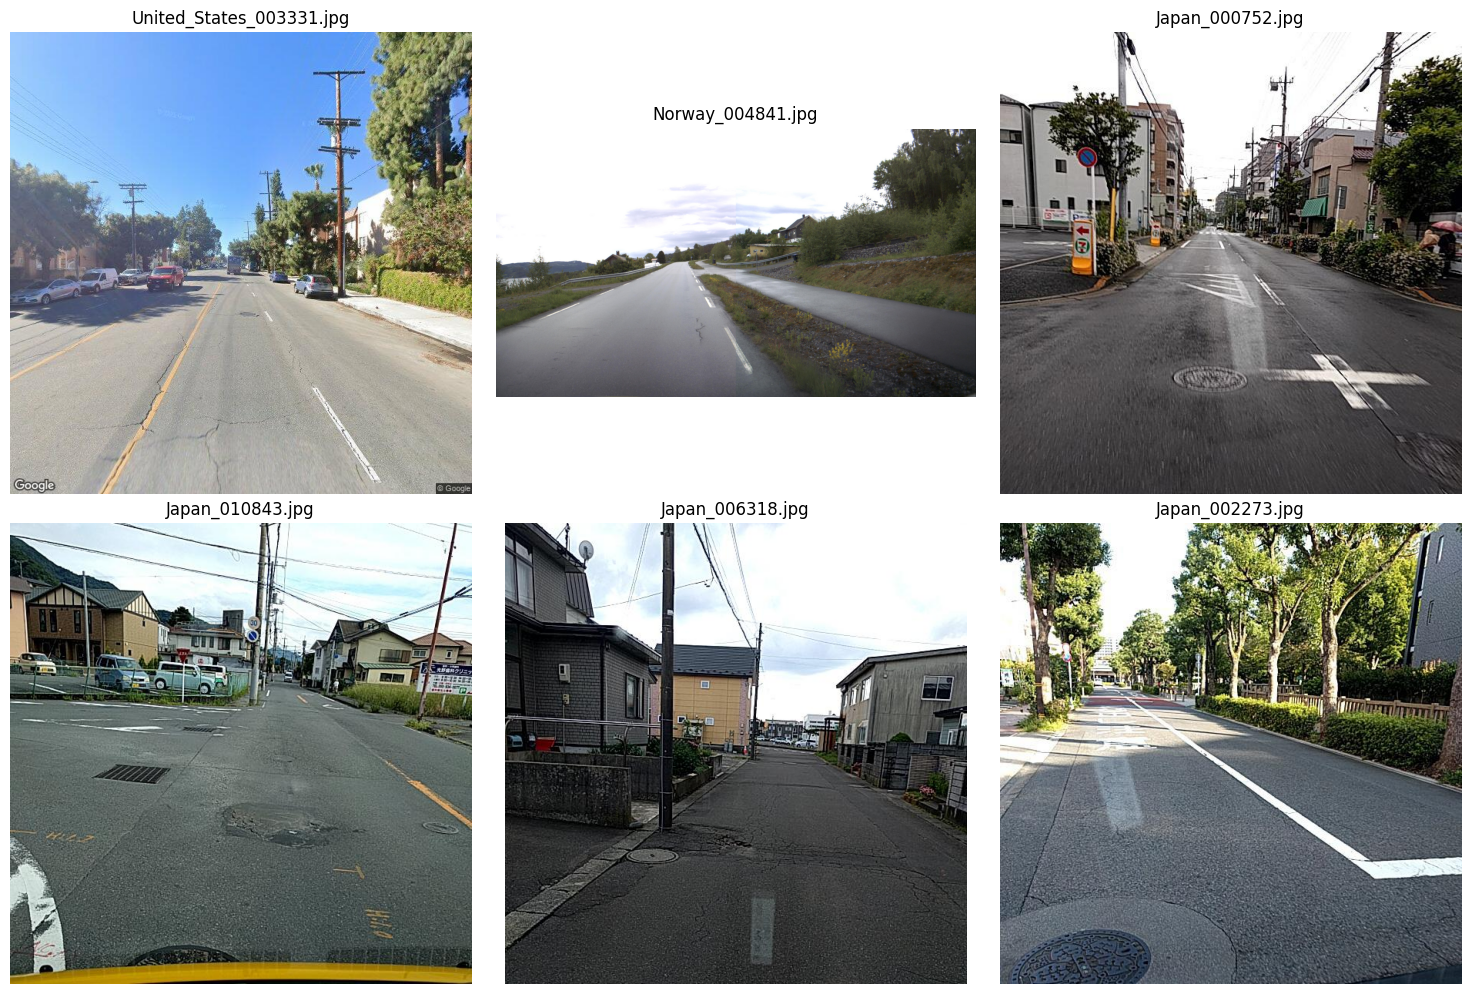

In [14]:
image_files = os.listdir(train_images)

plt.figure(figsize=(15,10))

for i in range(6):

    image_name = random.choice(image_files)

    image_path = os.path.join(train_images, image_name)

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(image)
    plt.title(image_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

# **Step 7-Image Size**

In [15]:
sample_image = os.path.join(train_images, image_files[0])

img = cv2.imread(sample_image)

print("Image Shape :", img.shape)
print("Height :", img.shape[0])
print("Width :", img.shape[1])
print("Channels :", img.shape[2])

Image Shape : (512, 512, 3)
Height : 512
Width : 512
Channels : 3


# **Step 8-Read First Label File**

In [16]:
label_files = os.listdir(train_labels)

first_label = os.path.join(train_labels, label_files[0])

with open(first_label, "r") as f:
    lines = f.readlines()

print("Label File:", label_files[0])
print("-" * 50)

for line in lines:
    print(line.strip())

Label File: China_Drone_000001.txt
--------------------------------------------------
1 0.207031 0.165039 0.359375 0.056641
0 0.209961 0.376953 0.048828 0.308594


# **Step 9-Count Objects in Dataset**

In [17]:
object_count = 0

for file in os.listdir(train_labels):

    path = os.path.join(train_labels, file)

    with open(path, "r") as f:

        object_count += len(f.readlines())

print("Total Objects in Train Dataset :", object_count)

Total Objects in Train Dataset : 46296


# **Step 10-Extract Class IDs**

In [18]:
class_ids = []

for file in os.listdir(train_labels):

    path = os.path.join(train_labels, file)

    with open(path, "r") as f:

        lines = f.readlines()

        for line in lines:

            class_id = int(line.split()[0])

            class_ids.append(class_id)

print("Total Labels :", len(class_ids))
print("Unique Classes :", sorted(set(class_ids)))

Total Labels : 46296
Unique Classes : [0, 1, 2, 3, 4]


# **Step 11-Class Distribution**

In [19]:
counter = Counter(class_ids)

counter

Counter({0: 18201, 1: 8386, 3: 7554, 2: 7527, 4: 4628})

# **Step 12-Plot Class Distribution**

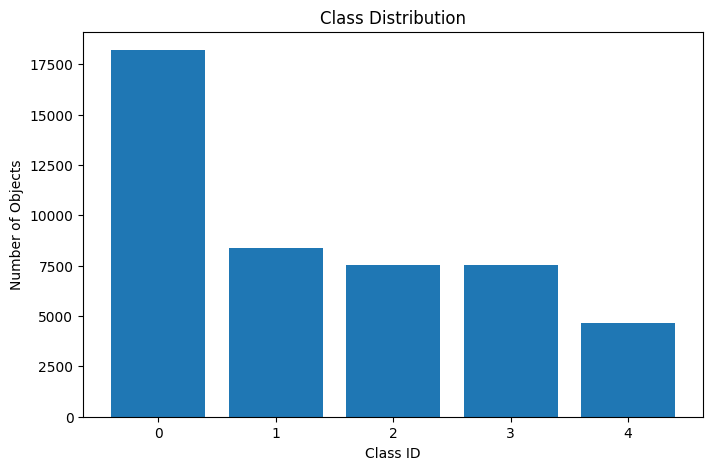

In [20]:
plt.figure(figsize=(8,5))

plt.bar(counter.keys(), counter.values())

plt.title("Class Distribution")

plt.xlabel("Class ID")

plt.ylabel("Number of Objects")

plt.show()

# **Step 13-Class Names**

In [21]:
CLASS_NAMES = {
    0: "Longitudinal Crack",
    1: "Transverse Crack",
    2: "Alligator Crack",
    3: "Other Corruption",
    4: "Pothole"
}

# **Step 14-Draw Bounding Boxes**

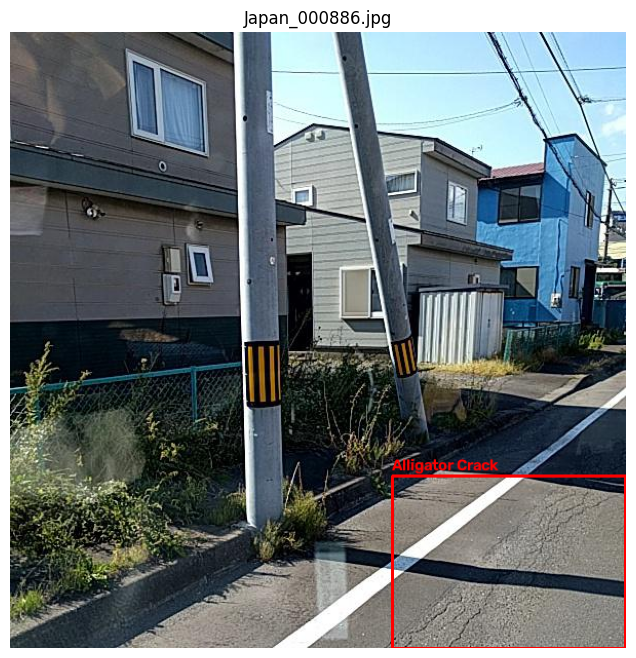

In [22]:
image_name = random.choice(os.listdir(train_images))

image_path = os.path.join(train_images, image_name)
label_path = os.path.join(train_labels, image_name.replace(".jpg", ".txt"))

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

h, w, _ = image.shape

with open(label_path, "r") as f:
    labels = f.readlines()

for label in labels:

    class_id, x, y, bw, bh = map(float, label.split())

    x = x * w
    y = y * h
    bw = bw * w
    bh = bh * h

    x1 = int(x - bw / 2)
    y1 = int(y - bh / 2)
    x2 = int(x + bw / 2)
    y2 = int(y + bh / 2)

    cv2.rectangle(image, (x1, y1), (x2, y2), (255,0,0), 2)

    cv2.putText(
        image,
        CLASS_NAMES.get(int(class_id), str(int(class_id))),
        (x1, y1-5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255,0,0),
        2
    )

plt.figure(figsize=(10,8))
plt.imshow(image)
plt.axis("off")
plt.title(image_name)
plt.show()

# **Step 15-Dataset Statistics**

In [23]:
print("="*60)
print("RDD2022 DATASET REPORT")
print("="*60)

print(f"Training Images      : {len(os.listdir(train_images))}")
print(f"Validation Images    : {len(os.listdir(val_images))}")
print(f"Testing Images       : {len(os.listdir(test_images))}")

print()

print(f"Training Labels      : {len(os.listdir(train_labels))}")
print(f"Validation Labels    : {len(os.listdir(val_labels))}")
print(f"Testing Labels       : {len(os.listdir(test_labels))}")

print()

total_images = (
    len(os.listdir(train_images))
    + len(os.listdir(val_images))
    + len(os.listdir(test_images))
)

total_labels = (
    len(os.listdir(train_labels))
    + len(os.listdir(val_labels))
    + len(os.listdir(test_labels))
)

print(f"Total Images         : {total_images}")
print(f"Total Labels         : {total_labels}")

print()

print(f"Number of Classes    : {len(counter)}")
print(f"Class IDs            : {list(counter.keys())}")

print("="*60)

RDD2022 DATASET REPORT
Training Images      : 26869
Validation Images    : 5758
Testing Images       : 5757

Training Labels      : 26869
Validation Labels    : 5758
Testing Labels       : 5758

Total Images         : 38384
Total Labels         : 38385

Number of Classes    : 5
Class IDs            : [1, 0, 2, 3, 4]


# **Step 16-Conclusion**

The RDD2022 dataset has been successfully analyzed.

Completed tasks:

- Dataset verified
- Images and labels counted
- Sample images visualized
- Image dimensions checked
- YOLO label files analyzed
- Class IDs extracted
- Class distribution visualized
- Bounding boxes displayed

The dataset is now ready for preprocessing and model training.